# 第四问：前一周同日电价预测与电价完全已知的策略比较

本 notebook 使用 `submit/q2_with_penalty.py`（依赖 `submit/q2.py`）和 `submit/q3.py` 的现有预测、优化与执行规则，重算波动电价下的第二、三问。执行环境为 **conda mcm**。核心计算直接调用原函数，不修改原文件；适配层将决策电价与结算电价分离。

## 1. 实验口径与参数

- **评价期**：2025-02-01 至 2025-12-31，334 天，每天144个10分钟时段；1月作为预测历史/预热期。此前讨论的363天预测误差不等于本次334天的策略评价口径。
- **替换预测**：预测日期的每个时段使用严格早于该日期 7 天的同一星期、对应时段电价。该规则自动保持工作日/周末类型一致。当天预测曲线保持不变，06/12/18时更新光伏信息时不引入未来真实电价。
- **电价完全已知**：每天00时已知当天真实电价；仍使用相同的负载、光伏预测及风险参数，不知道未来真实负载、光伏。这是同一策略的电价信息对照，**不是全信息全局最优成本下界**。
- **结算**：两组均按附件4的真实电价计算计划、紧急与调整费用。紧急倍数5，增加调整倍数1.5，减少调整违约倍数0.5，继承原Q3口径，不另减退电退款。
- **Q4-2**：保留原Q2的风险分位数选择、跨日储能传递，以及6000 kWh期末目标、0.45元/kWh绝对偏离软惩罚。软惩罚是优化正则项，不计入实际购电费。原程序从2月1日6000 kWh开始；1月仅作为预测历史，可理解为储能保持初始电量。
- **Q4-3**：保留00时确定性计划、06/12/18时概率情景更新（各调整未来6小时）、剩余时段计划锁定，以及实时储能优先吸收富余/弥补缺口的执行规则。1月沿用原Q3固定电价预热；两组共用相同预热过程，因此2月1日储能完全相同。原程序前14天预热会使用当日负载作替代，这部分不计入评价。Q4-3的00:00全天计划使用同样的0.45元/kWh软终点惩罚，储能状态在日间和跨日连续传递；06/12/18时的6小时调整窗口不设置日末硬约束。
- **参数评价限制**：Q2沿用原程序在5—8月开发期、附件1固定电价下选择风险分位数，然后在两种波动电价方案中冻结使用。因此334天属于包含开发期的回溯比较，不能称为完全独立的样本外评价。

负载/光伏模型输入仍是原代码规定的历史曲线与已发布预报；输出是未来144个时段的负载预测、光伏预测或净负荷情景，供购电和储能优化使用。下面保留开发期扫描结果和源文件指纹，以便复核。缓存仅在源文件与mcm运行路径匹配时使用，删除`.tmp/q4_prepared.pkl`即可重新计算。


In [1]:
from pathlib import Path
import os, sys, json, pickle, hashlib, time, io, base64, subprocess, shutil
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('OMP_NUM_THREADS', '1')
import numpy as np
import pandas as pd
import scipy
print('运行环境：',sys.executable)
assert Path(sys.prefix).name == 'mcm', '请在 mcm 环境运行本 notebook'

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'submit/q2_with_penalty.py').exists())
TMP = ROOT / '.tmp/q4_price_comparison'
TMP.mkdir(parents=True, exist_ok=True)
OUT = ROOT / 'submit/results'
OUT.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / 'submit'))
import q2, q2_with_penalty as q2p, q3
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
SOURCE_FILES = ['submit/q2.py','submit/q2_with_penalty.py','submit/q3.py',
                'submit/Data/附件1.xlsx','submit/Data/附件2.xlsx',
                'submit/Data/附件3.xlsx','submit/Data/附件4.xlsx']
hashes = {f: hashlib.sha256((ROOT/f).read_bytes()).hexdigest() for f in SOURCE_FILES}
prepared = ROOT / '.tmp/q4_prepared.pkl'
cache = pickle.loads(prepared.read_bytes()) if prepared.exists() else None
if cache is None or cache.get('hashes') != hashes or cache.get('runtime') != sys.executable:
    dates, load, pv, fixed_prices, forecasts = q3.read_inputs(
        ROOT/SOURCE_FILES[4], ROOT/SOURCE_FILES[3], ROOT/SOURCE_FILES[5])
    pred_load, pred_pv, scenarios = q2.forecast_scenarios(dates, load, pv)
    qstar, scan = q2.scan_q_star(dates, load, pv, fixed_prices, scenarios,
        terminal_target_kwh=q2p.TERMINAL_TARGET_KWH,
        terminal_penalty_yuan_per_kwh=q2p.TERMINAL_PENALTY_YUAN_PER_KWH)
    cache = dict(dates=dates,load=load,pv=pv,fixed_prices=fixed_prices,
        forecasts=forecasts,pred_load=pred_load,pred_pv=pred_pv,
        scenarios=scenarios,qstar=qstar,scan=scan,hashes=hashes,runtime=sys.executable)
    prepared.write_bytes(pickle.dumps(cache))
globals().update({k:v for k,v in cache.items() if k != 'hashes'})
print(f'原Q2程序选出的风险分位数：{qstar:.2f}；Q3历史误差缩放系数：{q3.CFG["error_scale"]}')
display(scan[['q','total_cost_yuan','delta_pct']].rename(columns={
    'q':'风险分位数','total_cost_yuan':'原固定电价开发期费用（元）','delta_pct':'较最优增加（%）'}))

运行环境： /Users/jinyu/miniconda3/envs/mcm/bin/python


原Q2程序选出的风险分位数：0.85；Q3历史误差缩放系数：0.25


,风险分位数,原固定电价开发期费用（元）,较最优增加（%）
0,0.0500,"8,725,549.6312",60.9790
1,0.1000,"8,126,015.7938",49.9181
2,0.1500,"7,704,767.3971",42.1465
3,0.2000,"7,356,188.6120",35.7155
4,0.2500,"7,049,871.5276",30.0642
5,0.3000,"6,791,977.3220",25.3063
6,0.3500,"6,558,746.2728",21.0033
7,0.4000,"6,354,857.2805",17.2418
8,0.4500,"6,179,180.6279",14.0007
9,0.5000,"6,020,054.1418",11.0649


## 2. 电价预测与时间对应

原始附件每行的144个价格依次对应00:00–00:10至23:50–24:00，行尾`0:00+1`仍属于**来源日的最后一个时段**，不划入次日的峰/谷分类。周一参考前一个周五，周六参考前一个周日，周日参考当天之前的周六。

下表检验参考日期及334天全部48,096个点的误差。MAE、MAPE、WAPE均由逐点结果整体计算，WAPE不平均分组比率，也不按用电量加权。


In [2]:
from openpyxl import load_workbook  # 仅读取原始附件与核验导出结果
wb = load_workbook(ROOT/'submit/Data/附件4.xlsx', read_only=True, data_only=True)
rows = list(wb.worksheets[0].iter_rows(values_only=True)); wb.close()
price_dates = pd.DatetimeIndex(pd.to_datetime([r[0] for r in rows[1:]]))
assert price_dates.equals(dates)
price_actual = np.asarray([r[1:145] for r in rows[1:]], float)
assert price_actual.shape == (365,144) and np.isfinite(price_actual).all()
assert (price_actual > 0).all()
for slot, header in enumerate(rows[0][1:145], 1):
    if slot < 144:
        assert header.hour*60+header.minute == slot*10
    else:
        assert '+1' in str(header)
price_pred = np.full_like(price_actual, np.nan)
# 前一周同日：d 日的每个时段均使用 d-7 日同一时刻的已实现价格。
# 每日都有记录，因此该参考日严格早于预测日且星期类型完全一致。
reference = np.arange(len(dates), dtype=int) - 7
valid = reference >= 0
price_pred[valid] = price_actual[reference[valid]]
RUN_IDX = np.flatnonzero((dates >= q2.RUN_START) & (dates <= q2.RUN_END))
assert len(RUN_IDX) == 334 and np.isfinite(price_pred[RUN_IDX]).all()
assert np.all(reference[RUN_IDX] < RUN_IDX)
assert np.array_equal(dates[reference[RUN_IDX]].weekday, dates[RUN_IDX].weekday)
assert reference[dates.get_loc('2025-02-01')] == dates.get_loc('2025-01-25')
assert reference[dates.get_loc('2025-02-03')] == dates.get_loc('2025-01-27')
mapping = pd.DataFrame({'预测日期':dates[RUN_IDX], '星期':dates[RUN_IDX].day_name(),
    '参考日期':dates[reference[RUN_IDX]]})
mapping.to_csv(TMP/'price_reference.csv', index=False)
y = price_actual[RUN_IDX].ravel(); error = price_pred[RUN_IDX].ravel()-y
price_metrics = pd.DataFrame([{'评价点数':len(y),'MAE（元/kWh）':abs(error).mean(),
    'MAPE（%）':np.mean(abs(error)/y)*100,'WAPE（%）':abs(error).sum()/y.sum()*100,
    'RMSE（元/kWh）':np.sqrt(np.mean(error**2))}])
display(mapping.head(8)); display(price_metrics)

,预测日期,星期,参考日期
0,2025-02-01,Saturday,2025-01-25
1,2025-02-02,Sunday,2025-01-26
2,2025-02-03,Monday,2025-01-27
3,2025-02-04,Tuesday,2025-01-28
4,2025-02-05,Wednesday,2025-01-29
5,2025-02-06,Thursday,2025-01-30
6,2025-02-07,Friday,2025-01-31
7,2025-02-08,Saturday,2025-02-01


,评价点数,MAE（元/kWh）,MAPE（%）,WAPE（%）,RMSE（元/kWh）
0,48096,0.0472,7.6491,6.2244,0.0653


## 3. Q4-2：日前计划与真实电价结算

输入为原Q2净负荷风险分位数曲线、预测/已知电价和上一日储能状态；输出为144时段的计划购电、充电、放电和储能轨迹。计划不足部分按原程序固定计划执行规则紧急购买。

实际费用为：
$$ C_2=\sum_t p_tg_t+5\sum_t p_th_t, $$
其中真实电价为$$p_t$$，计划购电量为$$g_t$$，紧急购电量为$$h_t$$（电量单位均为kWh）。预测电价只用于求解计划。


In [3]:
def run_q4_2(decision_prices):
    daily, details = [], []
    state = q2.CFG['initial_storage_kwh']
    dt = q2.CFG['interval_hours']
    for k in RUN_IDX:
        net = np.quantile(scenarios[k], qstar, axis=0)*dt
        plan = q2.solve_dispatch(net, decision_prices[k], initial_storage_kwh=state,
            terminal_target_kwh=q2p.TERMINAL_TARGET_KWH,
            terminal_penalty_yuan_per_kwh=q2p.TERMINAL_PENALTY_YUAN_PER_KWH)
        h, unused = q2.execute_fixed_plan(plan, (load[k]-pv[k])*dt)
        day = str(dates[k].date()); actual = price_actual[k]
        x = pd.DataFrame({'date':day,'slot':np.arange(1,145),
            'price_forecast':decision_prices[k],'price':actual,
            'actual_load_kwh':load[k]*dt,'actual_pv_kwh':pv[k]*dt,
            'planned_grid_kwh':plan['grid'],'updated_grid_kwh':plan['grid'],
            'charge_kwh':plan['charge'],'discharge_kwh':plan['discharge'],
            'emergency_kwh':h,'unused_kwh':unused,
            'storage_start_kwh':plan['storage'][:-1],'storage_end_kwh':plan['storage'][1:],
            'planned_cost':actual*plan['grid'],'adjustment_cost':np.zeros(144),
            'emergency_cost':q2.CFG['emergency_multiplier']*actual*h})
        state = float(plan['storage'][-1])
        d = summarize_day(x)
        d['terminal_soft_penalty'] = q2p.TERMINAL_PENALTY_YUAN_PER_KWH*abs(state-q2p.TERMINAL_TARGET_KWH)
        d['solver'] = plan['solver']
        daily.append(d); details.append(x)
    return pd.DataFrame(daily), pd.concat(details,ignore_index=True)

def summarize_day(x):
    return {'date':x.date.iloc[0],'planned_kwh':float(x.planned_grid_kwh.sum()),
        'updated_kwh':float(x.updated_grid_kwh.sum()),
        'increase_kwh':float((x.updated_grid_kwh-x.planned_grid_kwh).clip(lower=0).sum()),
        'decrease_kwh':float((x.planned_grid_kwh-x.updated_grid_kwh).clip(lower=0).sum()),
        'emergency_kwh':float(x.emergency_kwh.sum()),'unused_kwh':float(x.unused_kwh.sum()),
        'planned_cost':float(x.planned_cost.sum()),'adjustment_cost':float(x.adjustment_cost.sum()),
        'emergency_cost':float(x.emergency_cost.sum()),
        'total_cost':float(x[['planned_cost','adjustment_cost','emergency_cost']].to_numpy().sum()),
        'state_start':float(x.storage_start_kwh.iloc[0]),'state_end':float(x.storage_end_kwh.iloc[-1])}

t0=time.time()
results={}
for mode, p in [('替换预测',price_pred),('电价完全已知',price_actual)]:
    results[('Q4-2',mode)] = run_q4_2(p)
    print('Q4-2',mode,'实际总费用',f'{results[("Q4-2",mode)][0].total_cost.sum():,.2f}','元',flush=True)
print('第二问两组求解耗时',round(time.time()-t0,1),'秒')

Q4-2 替换预测 实际总费用 15,144,163.53 元


Q4-2 电价完全已知 实际总费用 14,966,760.46 元


第二问两组求解耗时 2.4 秒


## 4. Q4-3：日内概率更新与真实电价结算

输入为当天已发布的光伏预报、Q2负载预测、历史误差情景和当前实测储能状态；输出为当前6小时调整后的购电计划。实时执行仍调用原代码的`execute`，未将计划充放电曲线替换为新的控制规则。

实际费用为：
$$ C_3=\sum_t p_tg_t+\sum_t p_t\left[1.5(a_t-g_t)_++0.5(g_t-a_t)_+\right]+5\sum_t p_th_t. $$
这里$$a_t$$是最终调整购电量，$$g_t$$是00时原计划购电量。正部函数表示仅取正值。减少购电的0.5倍费用按照原程序作为额外违约费用计算。


In [4]:
def run_q4_3(decision_prices, update_hours=(6,12,18)):
    state=q3.CFG['e0']; daily=[]; details=[]
    for k, day in enumerate(dates):
        # 沿用原Q3的1月预热；两种电价方案预热完全相同，2月1日起才切换电价信息。
        p = fixed_prices if k < RUN_IDX[0] else decision_prices[k]
        baseline_a, baseline_w = q3.baseline2_deterministic_scenario(k,0,pred_load,forecasts,load,14)
        baseline = np.zeros(144) if k==0 else q3.solve_problem(
            baseline_a,p,state,risk=True,weights=baseline_w,
            terminal_target_kwh=q2p.TERMINAL_TARGET_KWH,
            terminal_penalty_yuan_per_kwh=q2p.TERMINAL_PENALTY_YUAN_PER_KWH,
            terminal_hard=False)['grid']
        updated=baseline.copy(); blocks=[]
        active_hours=(6,12,18) if k<RUN_IDX[0] else update_hours
        for hour in (0,6,12,18):
            start,end=hour*6,hour*6+36
            if hour in active_hours and k>0:
                a,w=q3.issue_scenarios(k,hour,pred_load,forecasts,load,pv,14,True)
                candidate=q3.solve_problem(a,p[start:],state,fixed=baseline[start:],
                    lock_from=36,risk=True,weights=w,terminal_hard=False)['grid']
                updated[start:end]=candidate[:36]
            c,d,h,u,e=q3.execute(updated[start:end],load[k,start:end]*q3.DT,
                pv[k,start:end]*q3.DT,state,battery=(k>0))
            state=float(e[-1]); blocks.append((c,d,h,u,e))
        if k<RUN_IDX[0]:
            continue
        c,d,h,u=[np.concatenate([b[j] for b in blocks]) for j in range(4)]
        es=np.concatenate([b[4][:-1] for b in blocks]); ee=np.concatenate([b[4][1:] for b in blocks])
        actual=price_actual[k]
        adjustment=actual*(q3.CFG['up']*np.maximum(updated-baseline,0)
                         +q3.CFG['down']*np.maximum(baseline-updated,0))
        x=pd.DataFrame({'date':str(day.date()),'slot':np.arange(1,145),
            'price_forecast':p,'price':actual,'actual_load_kwh':load[k]*q3.DT,
            'actual_pv_kwh':pv[k]*q3.DT,'planned_grid_kwh':baseline,
            'updated_grid_kwh':updated,'charge_kwh':c,'discharge_kwh':d,
            'emergency_kwh':h,'unused_kwh':u,'storage_start_kwh':es,'storage_end_kwh':ee,
            'planned_cost':actual*baseline,'adjustment_cost':adjustment,
            'emergency_cost':q3.CFG['emergency']*actual*h})
        daily.append(summarize_day(x)); details.append(x)
        if day.day==1:
            print('Q4-3',day.strftime('%Y-%m'),'已完成',flush=True)
    return pd.DataFrame(daily),pd.concat(details,ignore_index=True)

t0=time.time()
for mode,p in [('替换预测',price_pred),('电价完全已知',price_actual)]:
    results[('Q4-3',mode)]=run_q4_3(p)
    print('Q4-3',mode,'实际总费用',f'{results[("Q4-3",mode)][0].total_cost.sum():,.2f}','元',flush=True)
print('第三问两组求解耗时',round(time.time()-t0,1),'秒')
(TMP/'runs.pkl').write_bytes(pickle.dumps(results))

Q4-3 2025-02 已完成


Q4-3 2025-03 已完成


Q4-3 2025-04 已完成


Q4-3 2025-05 已完成


Q4-3 2025-06 已完成


...

Q4-3 2025-11 已完成


Q4-3 2025-12 已完成


Q4-3 电价完全已知 实际总费用 14,080,793.60 元


第三问两组求解耗时 28.5 秒


25656902

## 5. 总费用、峰谷日及月度比较与约束核验

**费用增加比例** = （替换预测实际总费 − 电价完全已知实际总费）÷ 电价完全已知实际总费。该比例才是本次电价预测对策略的经济影响，不能用电价WAPE直接代替。

核验覆盖334天所有时段的能量平衡、储能递推、容量与功率限制、充放电互斥、跨时段/跨日状态连续，以及各项费用与逐点真实电价的对应。两组期末储能分别展示，费用差未做额外库存残值调整。峰/谷日增费按费用发生日归类，包含跨日储能状态的影响，不等同于独立的组内因果效应。Q2与Q3的执行机制和期初状态不同，跨模型总费差不应全部归因于预报更新。


In [5]:
def verify_run(daily,x):
    assert len(daily)==334 and len(x)==334*144
    assert list(daily.date)==[str(v.date()) for v in dates[RUN_IDX]]
    assert not x.duplicated(['date','slot']).any()
    assert np.isfinite(x.select_dtypes('number')).all().all()
    b=x.updated_grid_kwh+x.actual_pv_kwh+x.discharge_kwh+x.emergency_kwh-x.actual_load_kwh-x.charge_kwh-x.unused_kwh
    s=x.storage_end_kwh-x.storage_start_kwh-.9*x.charge_kwh+x.discharge_kwh/.9
    assert abs(b).max()<1e-5 and abs(s).max()<1e-5
    assert x[['storage_start_kwh','storage_end_kwh']].min().min()>=1200-1e-5
    assert x[['storage_start_kwh','storage_end_kwh']].max().max()<=10800+1e-5
    assert x[['charge_kwh','discharge_kwh']].max().max()<=5000/6+1e-5
    assert not ((x.charge_kwh>1e-6)&(x.discharge_kwh>1e-6)).any()
    assert np.allclose(x.storage_start_kwh.to_numpy()[1:],x.storage_end_kwh.to_numpy()[:-1],atol=1e-5)
    assert np.allclose(x.planned_cost,x.price*x.planned_grid_kwh)
    assert np.allclose(x.emergency_cost,5*x.price*x.emergency_kwh)
    assert np.allclose(x.adjustment_cost,x.price*(1.5*(x.updated_grid_kwh-x.planned_grid_kwh).clip(lower=0)
                       +.5*(x.planned_grid_kwh-x.updated_grid_kwh).clip(lower=0)))
    costs=x.groupby('date')[['planned_cost','adjustment_cost','emergency_cost']].sum()
    assert np.allclose(costs.to_numpy(),daily[['planned_cost','adjustment_cost','emergency_cost']].to_numpy())
    assert np.isclose(costs.to_numpy().sum(),daily.total_cost.sum())
    return {'能量平衡最大残差':float(abs(b).max()),'储能递推最大残差':float(abs(s).max()),
            '时段数':len(x),'状态':'通过'}

check_rows=[]; summary_rows=[]
for (model,mode),(daily,x) in results.items():
    check_rows.append({'模型':model,'电价方案':mode,**verify_run(daily,x)})
    summary_rows.append({'模型':model,'电价方案':mode,'计划费用（元）':daily.planned_cost.sum(),
        '调整费用（元）':daily.adjustment_cost.sum(),'紧急费用（元）':daily.emergency_cost.sum(),
        '总费用（元）':daily.total_cost.sum(),'紧急购电量（kWh）':daily.emergency_kwh.sum(),
        '实际总购电量（kWh）':daily.updated_kwh.sum()+daily.emergency_kwh.sum(),
        '期初储能（kWh）':daily.state_start.iloc[0],'期末储能（kWh）':daily.state_end.iloc[-1]})
    daily.to_csv(TMP/f'{model}_{mode}_daily.csv',index=False)
    x.to_csv(TMP/f'{model}_{mode}_slots.csv',index=False)
for model in ('Q4-2','Q4-3'):
    assert np.isclose(results[(model,'替换预测')][0].state_start.iloc[0],
                      results[(model,'电价完全已知')][0].state_start.iloc[0])
summary=pd.DataFrame(summary_rows)
comparison=[]; daily_comparisons=[]
for model in ('Q4-2','Q4-3'):
    a=results[(model,'替换预测')][0].set_index('date')
    b=results[(model,'电价完全已知')][0].set_index('date')
    delta=a.total_cost-b.total_cost
    comparison.append({'模型':model,'替换预测总费用（元）':a.total_cost.sum(),
        '完全已知总费用（元）':b.total_cost.sum(),'增加费用（元）':delta.sum(),
        '相对增加（%）':delta.sum()/b.total_cost.sum()*100,'平均每日增加（元）':delta.mean(),
        '日增费95%分位数（元）':delta.quantile(.95),'最大日增费（元）':delta.max(),
        '最大日增费日期':delta.idxmax(),'增费日数':int((delta>1e-6).sum())})
    daily_comparisons.append(pd.DataFrame({'模型':model,'日期':delta.index,
        '日类型':np.where(pd.to_datetime(delta.index).weekday>=5,'谷日','峰日'),
        '替换预测费用':a.total_cost.to_numpy(),'完全已知费用':b.total_cost.to_numpy(),
        '增加费用':delta.to_numpy()}))
comparison=pd.DataFrame(comparison)
daily_comparison=pd.concat(daily_comparisons,ignore_index=True)
grouped=daily_comparison.groupby(['模型','日类型'])[['替换预测费用','完全已知费用','增加费用']].sum()
grouped['相对增加（%）']=100*grouped['增加费用']/grouped['完全已知费用']
monthly=daily_comparison.assign(月份=daily_comparison['日期'].str[:7]).groupby(['模型','月份'])[['替换预测费用','完全已知费用','增加费用']].sum()
monthly['相对增加（%）']=100*monthly['增加费用']/monthly['完全已知费用']
display(summary); display(comparison); display(grouped); display(monthly)
display(pd.DataFrame(check_rows))
summary.to_json(TMP/'summary.json',orient='records',force_ascii=False,indent=2)
comparison.to_json(TMP/'comparison.json',orient='records',force_ascii=False,indent=2)
grouped.to_csv(TMP/'group_comparison.csv')

,模型,电价方案,计划费用（元）,调整费用（元）,紧急费用（元）,总费用（元）,紧急购电量（kWh）,实际总购电量（kWh）,期初储能（kWh）,期末储能（kWh）
0,Q4-2,替换预测,"14,213,613.1447",0.0000,"930,550.3888","15,144,163.5335","225,320.9902","22,332,514.3995","6,000.0000","5,700.0000"
1,Q4-2,电价完全已知,"14,036,210.0712",0.0000,"930,550.3888","14,966,760.4600","225,320.9902","22,329,861.2408","6,000.0000","3,450.0000"
2,Q4-3,替换预测,"13,046,186.0159","760,945.2023","398,531.1054","14,205,662.3237","79,445.4306","21,061,015.3975","2,512.6545","5,618.6634"
3,Q4-3,电价完全已知,"12,879,643.9405","764,459.0278","436,690.6271","14,080,793.5954","87,792.2242","21,080,356.7392","2,512.6545","3,412.1436"


,模型,替换预测总费用（元）,完全已知总费用（元）,增加费用（元）,相对增加（%）,平均每日增加（元）,日增费95%分位数（元）,最大日增费（元）,最大日增费日期,增费日数
0,Q4-2,"15,144,163.5335","14,966,760.4600","177,403.0735",1.1853,531.1469,"2,041.8108","3,894.2079",2025-12-02,264
1,Q4-3,"14,205,662.3237","14,080,793.5954","124,868.7282",0.8868,373.8585,"1,964.3054","3,849.0826",2025-09-03,244


替换预测费用          完全已知费用         增加费用  相对增加（%）
模型   日类型                                                      
Q4-2 峰日  11,602,394.7445 11,470,858.1629 131,536.5816   1.1467
     谷日   3,541,768.7890  3,495,902.2971  45,866.4919   1.3120
Q4-3 峰日  10,911,920.1824 10,820,194.9238  91,725.2586   0.8477
     谷日   3,293,742.1413  3,260,598.6717  33,143.4696   1.0165

替换预测费用         完全已知费用        增加费用  相对增加（%）
模型   月份                                                        
Q4-2 2025-02 1,330,230.5413 1,315,605.9862 14,624.5551   1.1116
     2025-03 1,212,941.3383 1,196,180.7435 16,760.5948   1.4012
     2025-04   990,374.9540   976,385.5154 13,989.4386   1.4328
     2025-05 1,037,863.4109 1,021,253.9577 16,609.4532   1.6264
     2025-06 1,532,108.1900 1,513,590.2595 18,517.9305   1.2234
     2025-07 1,774,149.8709 1,759,507.6318 14,642.2390   0.8322
     2025-08 1,520,035.3338 1,506,788.8673 13,246.4665   0.8791
     2025-09 1,220,797.0232 1,203,221.0131 17,576.0100   1.4607
     2025-10 1,193,009.0729 1,178,469.2524 14,539.8205   1.2338
     2025-11 1,372,193.4490 1,354,911.1277 17,282.3212   1.2755
     2025-12 1,960,460.3494 1,940,846.1054 19,614.2440   1.0106
Q4-3 2025-02 1,280,279.1883 1,270,455.9062  9,823.2821   0.7732
     2025-03 1,123,116.0144 1,107,974.0899 15,141.9244   1.3666
     2025-04   910,484.0455   900,495.7327  9,988.3128   1.1092
     2025-05   942,566.1759   931,933.4168 10,632.7591   1.1409
     2025-06 1,366,237.7406 1,351,684.2690 14,553.4716   1.0767
     2025-07 1,665,021.0721 1,660,896.3882  4,124.6839   0.2483
     2025-08 1,413,634.3121 1,410,614.1312  3,020.1808   0.2141
     2025-09 1,156,512.8139 1,143,194.1385 13,318.6754   1.1650
     2025-10 1,138,784.2228 1,126,972.1537 11,812.0691   1.0481
     2025-11 1,324,807.0663 1,310,202.1369 14,604.9295   1.1147
     2025-12 1,884,219.6717 1,866,371.2322 17,848.4395   0.9563

,模型,电价方案,能量平衡最大残差,储能递推最大残差,时段数,状态
0,Q4-2,替换预测,0.0000,0.0000,48096,通过
1,Q4-2,电价完全已知,0.0000,0.0000,48096,通过
2,Q4-3,替换预测,0.0000,0.0000,48096,通过
3,Q4-3,电价完全已知,0.0000,0.0000,48096,通过


## 6. 题目指定日期：表1、表2、表3

以下为**替换预测方案**在3月20日、6月21日、9月23日、12月21日的结果。计划购电与调整后购电均不包含另外列示的紧急购电。全天费用同时列出计划、调整、紧急费用及其总和。表3将当天连续紧急购电时段合并，电量求和。


In [6]:
SELECTED=['2025-03-20','2025-06-21','2025-09-23','2025-12-21']
SPECIFIC_STARTS=[600,720,840,960,1080,1200]
def clock(minutes):
    return f'{minutes//60:02d}:{minutes%60:02d}'
def events_for_day(x):
    a=x.emergency_kwh.to_numpy(); events=[]; t=0
    while t<144:
        if a[t]<=1e-7:
            t+=1;continue
        start=t
        while t<144 and a[t]>1e-7:t+=1
        events.append((f'{clock(start*10)}-{clock(t*10)}',float(a[start:t].sum())))
    return events
paper1=[];paper2=[];paper3=[];paper_cost=[]
for model in ('Q4-2','Q4-3'):
    daily,detail=results[(model,'替换预测')]
    for day in SELECTED:
        x=detail[detail.date.eq(day)].sort_values('slot'); d=daily.set_index('date').loc[day]
        for minute in SPECIFIC_STARTS:
            r=x.iloc[minute//10]
            paper1.append({'模型':model,'日期':day,'时间段':f'{clock(minute)}-{clock(minute+10)}',
                '计划购电量（kWh）':r.planned_grid_kwh,'最终购电量（kWh）':r.updated_grid_kwh,
                '紧急购电量（kWh）':r.emergency_kwh})
        paper_cost.append({'模型':model,'日期':day,'全天计划购电量（kWh）':d.planned_kwh,
            '全天调整后购电量（kWh）':d.updated_kwh,'全天紧急购电量（kWh）':d.emergency_kwh,
            '计划费（元）':d.planned_cost,'调整费（元）':d.adjustment_cost,
            '紧急费（元）':d.emergency_cost,'总费（元）':d.total_cost,
            '0:00储电量（kWh）':d.state_start,'24:00储电量（kWh）':d.state_end})
        for b in range(6):
            z=x.iloc[b*24:(b+1)*24]
            paper2.append({'模型':model,'日期':day,'时间段':f'{clock(b*240)}-{clock((b+1)*240)}',
                '充电量（kWh）':z.charge_kwh.sum(),'放电量（kWh）':z.discharge_kwh.sum()})
        for interval,amount in events_for_day(x) or [('无紧急购电',0.)]:
            paper3.append({'模型':model,'日期':day,'紧急购电时间段':interval,'紧急购电量（kWh）':amount})
for title,data in [('指定日期全天结果',paper_cost),('表1：指定时段购电量',paper1),
                   ('表2：4小时充放电量',paper2),('表3：连续紧急购电区间',paper3)]:
    print(title)
    with pd.option_context('display.max_rows',None):display(pd.DataFrame(data))

指定日期全天结果


,模型,日期,全天计划购电量（kWh）,全天调整后购电量（kWh）,全天紧急购电量（kWh）,计划费（元）,调整费（元）,紧急费（元）,总费（元）,0:00储电量（kWh）,24:00储电量（kWh）
0,Q4-2,2025-03-20,"68,854.0919","68,854.0919",744.7465,"43,076.4152",0.0000,"3,427.0946","46,503.5098","4,950.0000","4,200.0000"
1,Q4-2,2025-06-21,"34,997.5389","34,997.5389",167.3847,"17,686.4783",0.0000,690.2925,"18,376.7708","6,000.0000","3,416.8812"
2,Q4-2,2025-09-23,"71,272.7006","71,272.7006",468.3659,"46,901.3842",0.0000,"2,043.1347","48,944.5190","2,018.4289","1,200.0000"
3,Q4-2,2025-12-21,"95,036.9408","95,036.9408",460.3338,"72,745.6043",0.0000,"1,913.6416","74,659.2459","6,000.0000","2,700.0000"
4,Q4-3,2025-03-20,"65,702.8048","65,787.2387","1,161.8272","41,262.2916",130.5306,"6,263.7353","47,656.5575","5,223.5657","4,185.9990"
5,Q4-3,2025-06-21,"31,134.0743","31,542.3652",63.1802,"15,527.1653",681.5800,185.5979,"16,394.3432","6,596.9388","4,422.6862"
6,Q4-3,2025-09-23,"67,042.6987","67,228.6701",596.9063,"43,715.9974",281.9788,"3,218.8127","47,216.7889","1,964.6359","1,483.5303"
7,Q4-3,2025-12-21,"89,351.9302","91,298.7190",437.5476,"67,573.7520","2,752.1067","3,027.9505","73,353.8091","5,935.1326","2,812.2559"


表1：指定时段购电量


,模型,日期,时间段,计划购电量（kWh）,最终购电量（kWh）,紧急购电量（kWh）
0,Q4-2,2025-03-20,10:00-10:10,0.0000,0.0000,0.0000
1,Q4-2,2025-03-20,12:00-12:10,643.1510,643.1510,0.0000
2,Q4-2,2025-03-20,14:00-14:10,0.0000,0.0000,0.0000
3,Q4-2,2025-03-20,16:00-16:10,497.0414,497.0414,65.2201
4,Q4-2,2025-03-20,18:00-18:10,0.0000,0.0000,3.1750
5,Q4-2,2025-03-20,20:00-20:10,734.6323,734.6323,29.7042
6,Q4-2,2025-06-21,10:00-10:10,0.0000,0.0000,0.0000
7,Q4-2,2025-06-21,12:00-12:10,0.0000,0.0000,0.0000
8,Q4-2,2025-06-21,14:00-14:10,0.0000,0.0000,0.0000
9,Q4-2,2025-06-21,16:00-16:10,207.8373,207.8373,0.0000


表2：4小时充放电量


,模型,日期,时间段,充电量（kWh）,放电量（kWh）
0,Q4-2,2025-03-20,00:00-04:00,"4,833.3333",0.0000
1,Q4-2,2025-03-20,04:00-08:00,"2,500.0000","5,407.5071"
2,Q4-2,2025-03-20,08:00-12:00,"5,213.2851","2,853.9495"
3,Q4-2,2025-03-20,12:00-16:00,"4,648.9512",401.9549
4,Q4-2,2025-03-20,16:00-20:00,0.0000,"7,897.7686"
5,Q4-2,2025-03-20,20:00-24:00,"3,333.3333",742.2314
6,Q4-2,2025-06-21,00:00-04:00,833.3333,"3,150.9241"
7,Q4-2,2025-06-21,04:00-08:00,833.3333,"2,519.0759"
8,Q4-2,2025-06-21,08:00-12:00,"5,474.1099",0.0000
9,Q4-2,2025-06-21,12:00-16:00,"5,192.5567",0.0000


表3：连续紧急购电区间


,模型,日期,紧急购电时间段,紧急购电量（kWh）
0,Q4-2,2025-03-20,00:20-00:30,20.7635
1,Q4-2,2025-03-20,01:10-01:30,36.2528
2,Q4-2,2025-03-20,02:30-02:40,7.4573
3,Q4-2,2025-03-20,03:10-03:40,22.3094
4,Q4-2,2025-03-20,04:50-05:20,27.2869
5,Q4-2,2025-03-20,05:50-06:00,13.1893
6,Q4-2,2025-03-20,06:40-06:50,0.7469
7,Q4-2,2025-03-20,08:10-08:40,79.1715
8,Q4-2,2025-03-20,09:00-09:10,22.7429
9,Q4-2,2025-03-20,15:20-17:20,379.6120


## 7. 电价预测引起的累计费用差

曲线为截至各日累计的“替换预测费用−完全已知费用”，单位万元。日费用差可能为负：两组执行状态会分化，且完全已知仅指电价，没有预知真实负载和光伏。


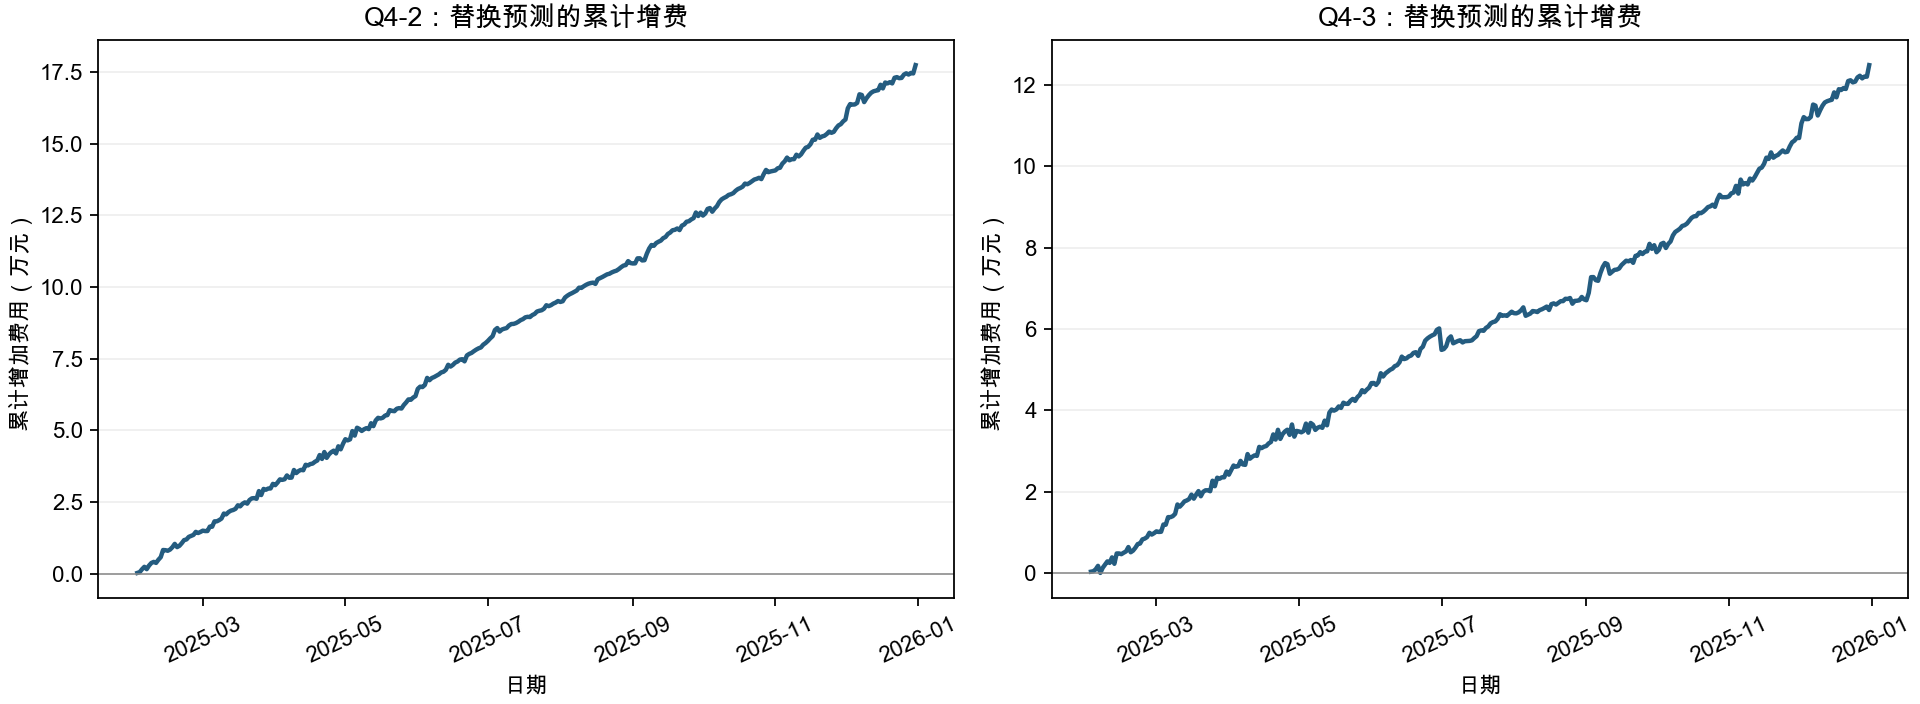

In [7]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import font_manager
available={f.name for f in font_manager.fontManager.ttflist}
font=next((f for f in ['Arial Unicode MS','PingFang SC','Heiti TC','DejaVu Sans'] if f in available),'DejaVu Sans')
plt.rcParams.update({'font.family':font,'axes.unicode_minus':False,'font.size':10})
fig,axs=plt.subplots(1,2,figsize=(12,4.4),layout='constrained')
for ax,model in zip(axs,('Q4-2','Q4-3')):
    z=daily_comparison[daily_comparison['模型'].eq(model)]
    ax.plot(pd.to_datetime(z['日期']),z['增加费用'].cumsum()/10000,color='#245c80',lw=2)
    ax.axhline(0,color='#888888',lw=.7)
    ax.set(title=f'{model}：替换预测的累计增费',ylabel='累计增加费用（万元）',xlabel='日期')
    ax.grid(axis='y',alpha=.2)
    ax.tick_params(axis='x',rotation=25)
buf=io.BytesIO();fig.savefig(buf,format='png',dpi=160)
display({'image/png':base64.b64encode(buf.getvalue()).decode()},raw=True)
plt.close(fig)

## 8. 题目要求的Excel输出

官方模板计划/调整工作表列顺序为`slot2,...,slot144,slot1`，对应表头从0:10开始、0:00放在最后。这里统一继承Q2导出的循环列映射；原Q3导出直接按slot1开始写入，与模板表头不一致，故本适配层按表头修正，不改变策略数值。模板最后一列`0:00-0:10+1`按原Q2约定填写来源日slot1，不跨日期挪用下一日数据。

- `submit/results/result4-2.xlsx`：替换预测的第二问结果。
- `submit/results/result4-3.xlsx`：替换预测的第三问结果。
- 完全已知方案、逐日/逐点比较和辅助输出均在`.tmp/q4_price_comparison/`。

计划表“全天购电费”填计划费用；Q3调整表“全天购电费”沿用原程序，填计划+调整+紧急的实际总费用。完整费用分解以上文结果为准。


In [8]:
# 整理官方模板要求的三/四张工作表；工作表外的详细审计数据保存在 .tmp。
def excel_payload(model,mode):
    daily,detail=results[(model,mode)]; dm=daily.set_index('date')
    plan_rows=[];updated_rows=[];bat_rows=[];em_rows=[]
    for day,x in detail.groupby('date',sort=True):
        x=x.sort_values('slot'); d=dm.loc[day]
        # 对齐模板的 [slot2,...,slot144,slot1] 顺序，与原Q2导出约定一致。
        def rotated(col):
            v=x[col].to_numpy();return np.r_[v[1:],v[:1]].tolist()
        plan_rows.append([day,*rotated('planned_grid_kwh'),float(d.planned_kwh),float(d.planned_cost)])
        updated_rows.append([day,*rotated('updated_grid_kwh'),float(d.updated_kwh),float(d.total_cost)])
        for b in range(6):
            z=x.iloc[b*24:(b+1)*24]
            bat_rows.append([day if b==0 else None,f'{clock(b*240)}-{clock((b+1)*240)}',
                float(z.charge_kwh.sum()),float(z.discharge_kwh.sum()),
                '0:00' if b==0 else ('24:00' if b==1 else None),
                float(d.state_start) if b==0 else (float(d.state_end) if b==1 else None)])
        for j,(interval,amount) in enumerate(events_for_day(x) or [(None,None)]):
            em_rows.append([day if j==0 else None,interval,amount])
    sheets={'计划购电量':plan_rows,'充放电量':bat_rows,'紧急购电量':em_rows}
    if model=='Q4-3':sheets['调整购电量']=updated_rows
    return sheets

exports=[]
for model,mode in results:
    # 用户要求的替换预测结果按题目文件名输出；完全已知方案仅作为对照存于 .tmp。
    target=OUT/f'result{model[1:]}.xlsx' if mode=='替换预测' else TMP/f'result{model[1:]}_oracle.xlsx'
    exports.append({'model':model,'mode':mode,'template':str(ROOT/f'submit/Data/附件5/result{model[1:]}.xlsx'),
        'output':str(target),'sheets':excel_payload(model,mode)})
(TMP/'excel_payload.json').write_text(json.dumps(exports,ensure_ascii=False),encoding='utf-8')
print('待导出的题目结果：result4-2.xlsx、result4-3.xlsx；对照方案明细留存在 .tmp。')

待导出的题目结果：result4-2.xlsx、result4-3.xlsx；对照方案明细留存在 .tmp。
